In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

In [9]:
for name, df in {
    "Funds": funds,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folios": folios,
    "Returns": returns,
    "Investors": investors,
    "Portfolio": portfolio
}.items():
    print("\n" + "="*60)
    print(name)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())


Funds
Shape: (40, 15)
Columns: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV
Shape: (46000, 3)
Columns: ['amfi_code', 'date', 'nav']

AUM
Shape: (90, 5)
Columns: ['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

SIP
Shape: (48, 6)
Columns: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Category
Shape: (144, 3)
Columns: ['month', 'category', 'net_inflow_crore']

Folios
Shape: (21, 6)
Columns: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

Returns
Shape: (40, 19)
Columns: ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'bet

In [8]:
import pandas as pd

funds = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folios = pd.read_csv("../data/raw/06_industry_folio_count.csv")
returns = pd.read_csv("../data/raw/07_scheme_performance.csv")
investors = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("All files loaded successfully")

All files loaded successfully


In [10]:
print("Funds:", funds.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folios:", folios.shape)
print("Returns:", returns.shape)
print("Investors:", investors.shape)
print("Portfolio:", portfolio.shape)

Funds: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folios: (21, 6)
Returns: (40, 19)
Investors: (32778, 13)
Portfolio: (322, 8)


In [11]:
nav["date"] = pd.to_datetime(nav["date"])

nav_trend = (
    nav.groupby("date")["nav"]
    .mean()
    .reset_index()
)

nav_trend.head()

,date,nav
0,2022-01-03,207.213793
1,2022-01-04,206.890585
2,2022-01-05,207.226548
3,2022-01-06,207.190405
4,2022-01-07,207.081100


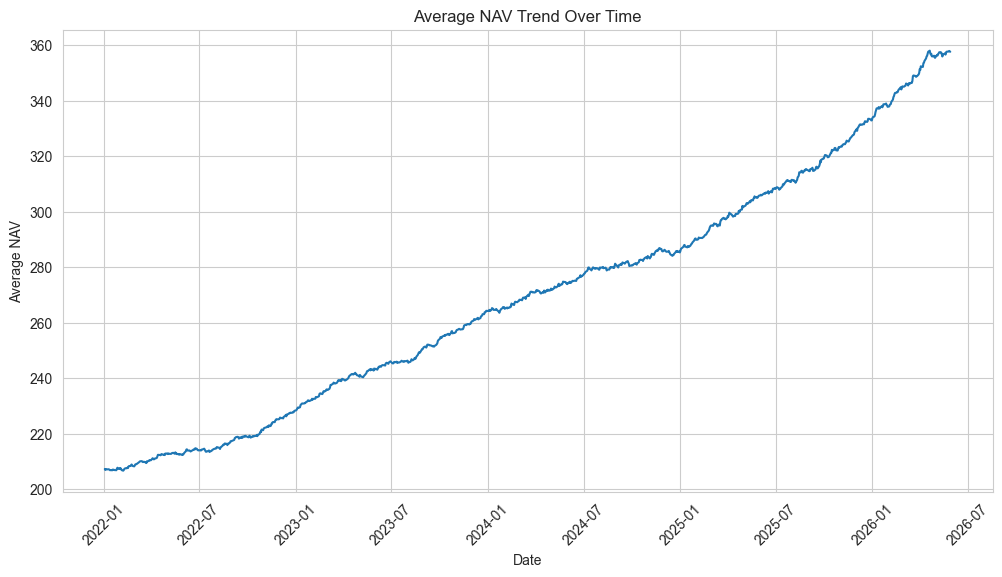

In [12]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=nav_trend,
    x="date",
    y="nav"
)

plt.title("Average NAV Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average NAV")

plt.xticks(rotation=45)

plt.show()

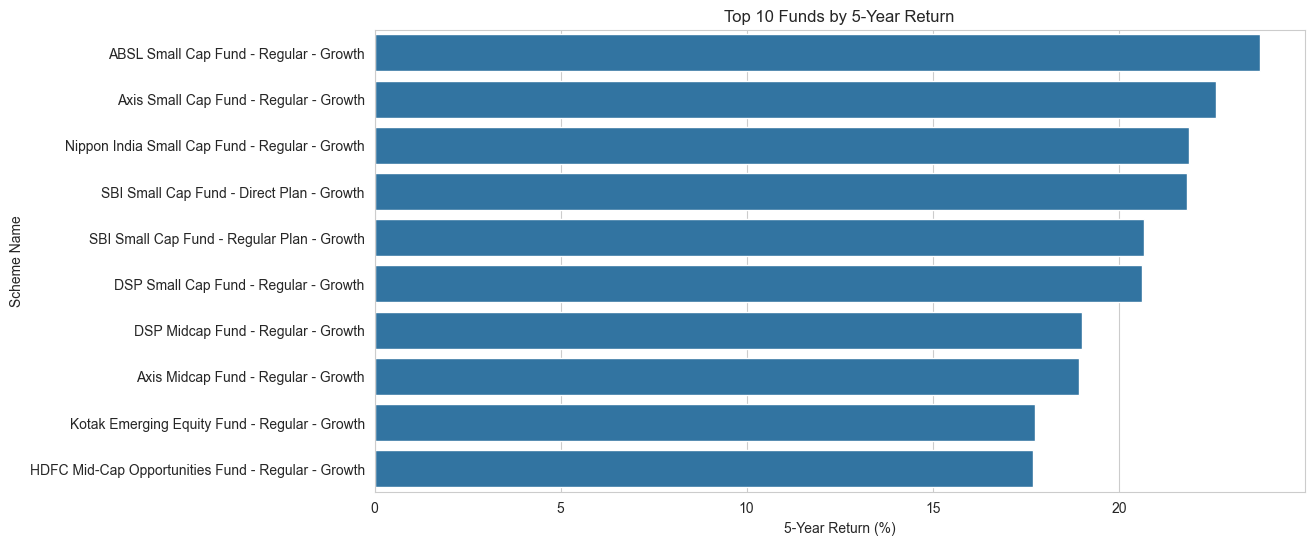

In [13]:
top_funds = (
    returns.sort_values(
        by="return_5yr_pct",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year Return")
plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme Name")

plt.show()

In [ ]:
### Insight

The top-performing schemes generated the highest 5-year returns, indicating strong long-term performance and effective fund management strategies.

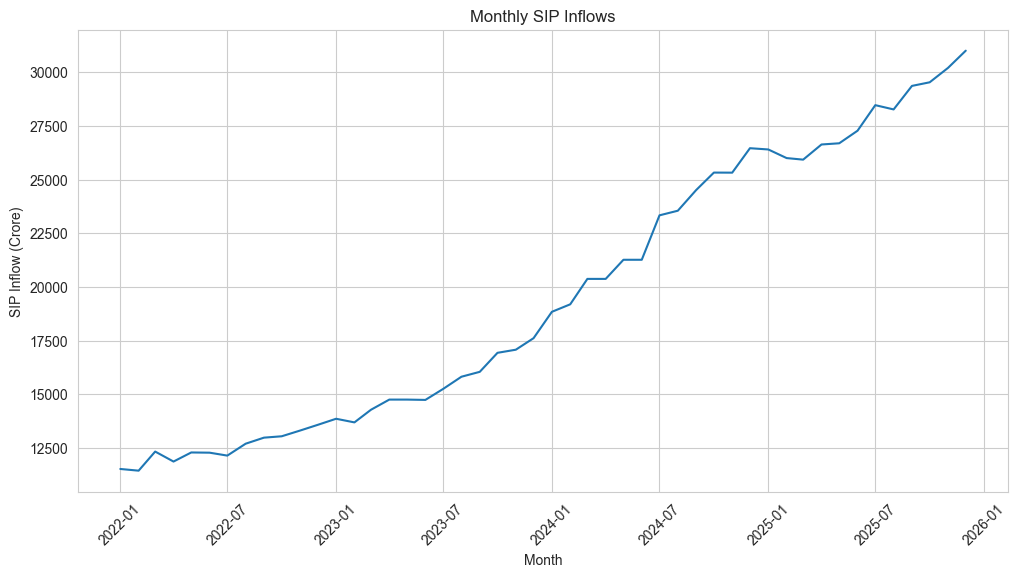

In [14]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,6))

sns.lineplot(
    data=sip,
    x="month",
    y="sip_inflow_crore"
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.xticks(rotation=45)

plt.show()

In [ ]:
### Insight

SIP inflows show a growing trend over time, reflecting increasing investor confidence and adoption of systematic investment plans.

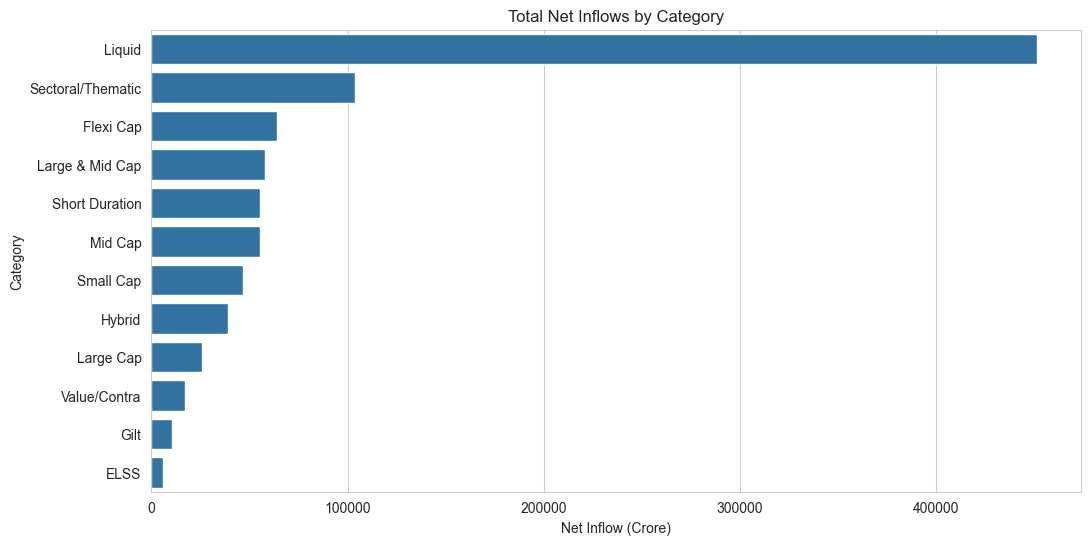

In [15]:
plt.figure(figsize=(12,6))

category_summary = (
    category.groupby("category")["net_inflow_crore"]
    .sum()
    .sort_values(ascending=False)
)

sns.barplot(
    x=category_summary.values,
    y=category_summary.index
)

plt.title("Total Net Inflows by Category")
plt.xlabel("Net Inflow (Crore)")
plt.ylabel("Category")

plt.show()

In [ ]:
### Insight

Certain mutual fund categories attract significantly higher inflows, indicating stronger investor preference and market demand.

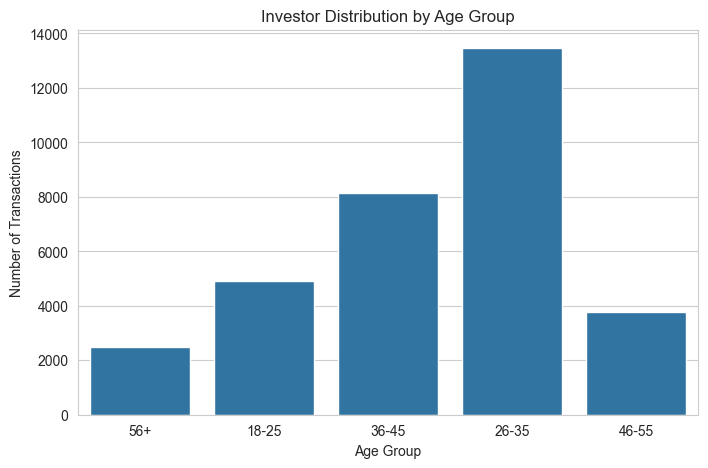

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=investors,
    x="age_group"
)

plt.title("Investor Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")

plt.show()

In [ ]:
### Insight

The age-group distribution helps identify the primary demographic participating in mutual fund investments.

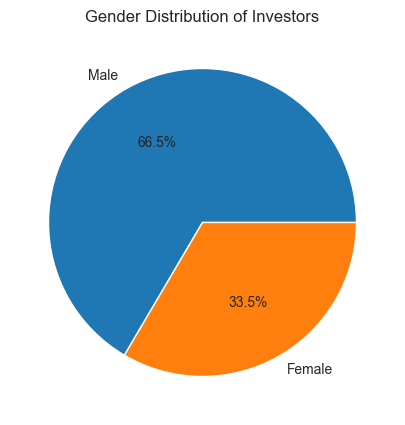

In [17]:
plt.figure(figsize=(6,5))

gender_counts = investors["gender"].value_counts()

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution of Investors")

plt.show()

In [ ]:
### Insight

Gender participation analysis reveals the representation of different investor groups in mutual fund investments.

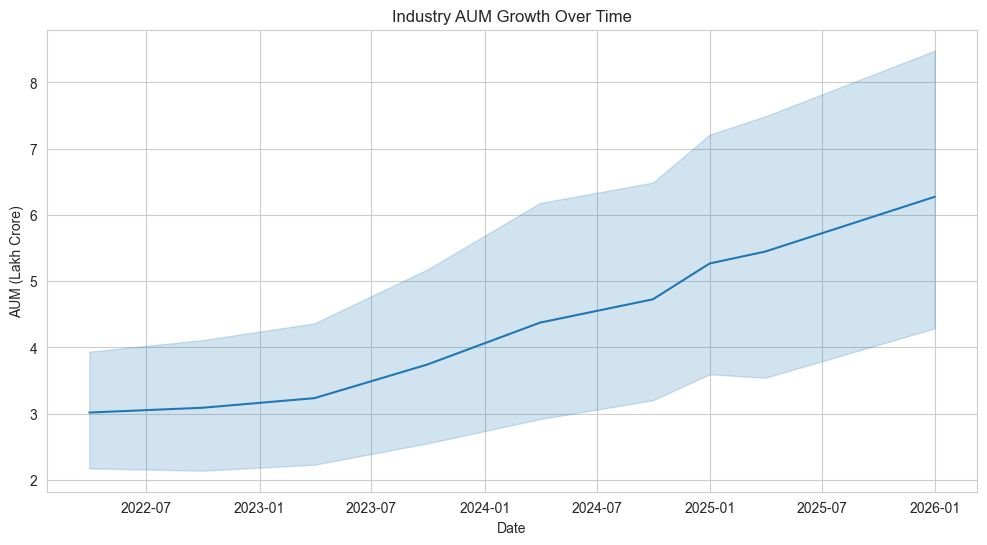

In [18]:
aum["date"] = pd.to_datetime(aum["date"])

plt.figure(figsize=(12,6))

sns.lineplot(
    data=aum,
    x="date",
    y="aum_lakh_crore"
)

plt.title("Industry AUM Growth Over Time")
plt.xlabel("Date")
plt.ylabel("AUM (Lakh Crore)")

plt.show()

In [ ]:
### Insight

The overall Assets Under Management (AUM) have grown steadily, indicating increasing investor participation and expansion of the mutual fund industry.

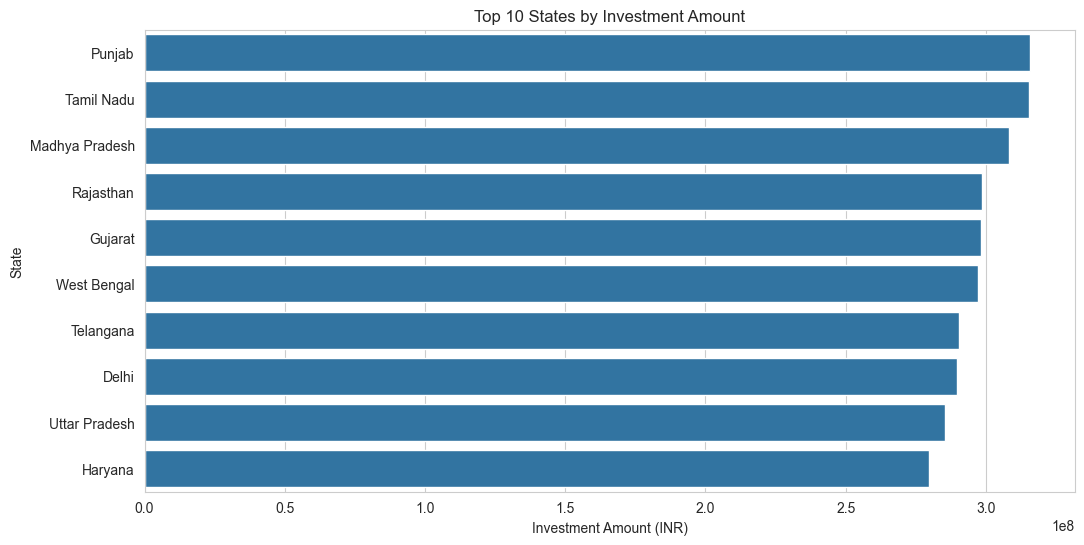

In [19]:
top_states = (
    investors.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Investment Amount")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.show()

In [ ]:
### Insight

A small number of states contribute a large share of investment activity, highlighting regional concentration in mutual fund participation.

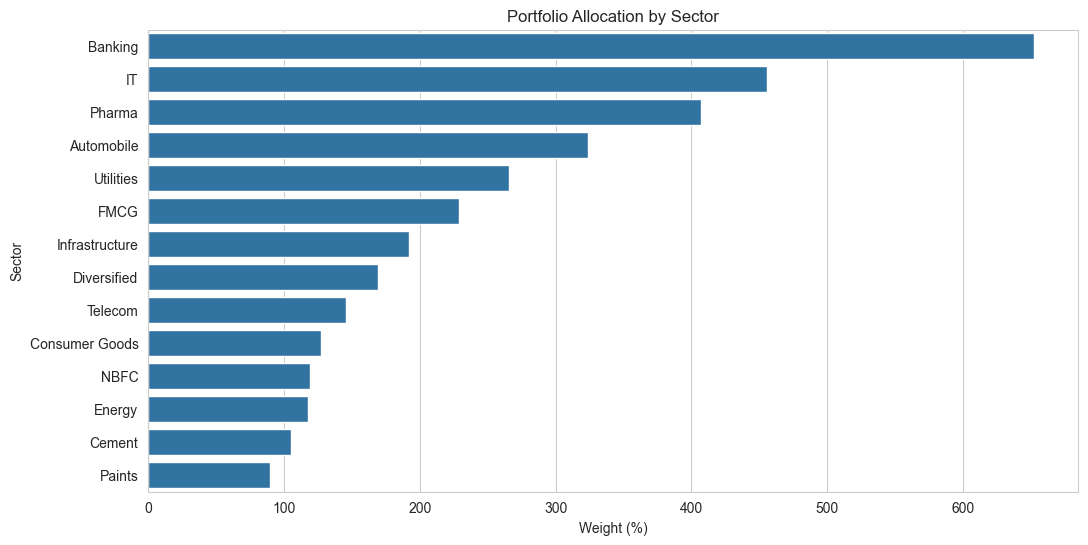

In [20]:
sector_weights = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=sector_weights.values,
    y=sector_weights.index
)

plt.title("Portfolio Allocation by Sector")
plt.xlabel("Weight (%)")
plt.ylabel("Sector")

plt.show()

In [ ]:
### Insight

Sector allocation reveals where mutual funds are concentrating their investments and helps identify dominant sectors in fund portfolios.

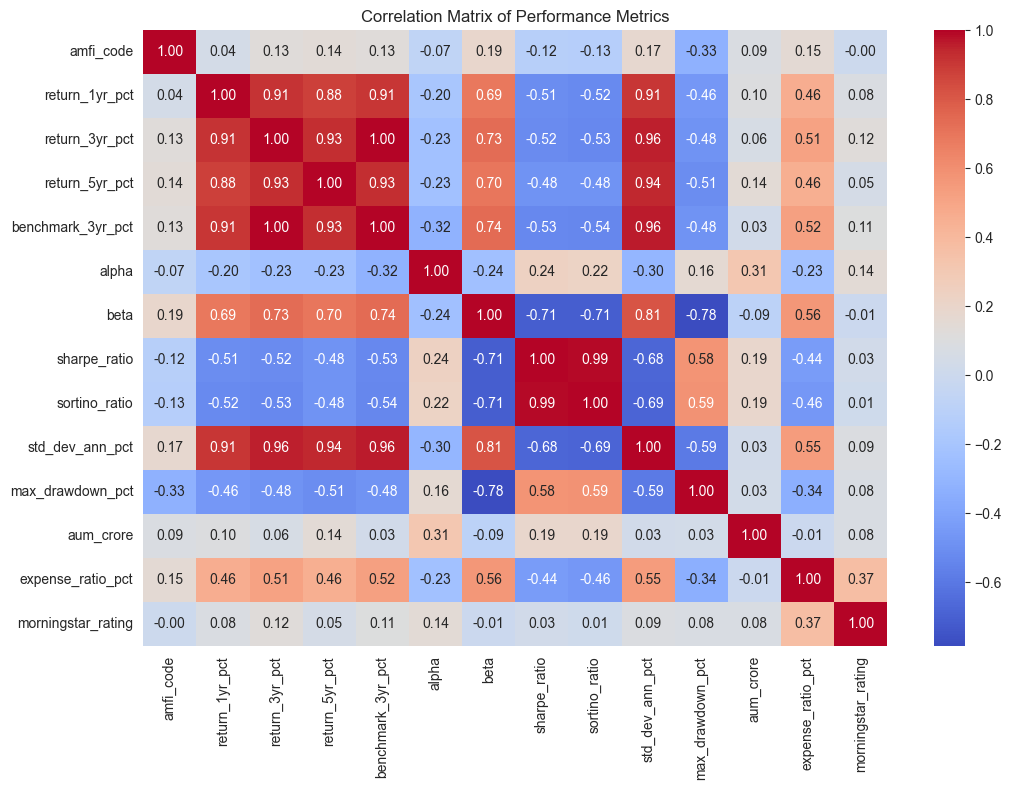

In [21]:
numeric_cols = returns.select_dtypes(include=["number"])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Performance Metrics")

plt.show()

In [ ]:
### Insight

The correlation matrix highlights relationships among returns, risk measures, expenses, and fund performance indicators.

In [ ]:
# Key Business Insights

1. Mutual fund NAVs show a long-term upward trend.
2. SIP inflows have increased consistently over time.
3. Top-performing funds significantly outperform average returns.
4. Investor participation is concentrated in specific age groups.
5. Investment activity varies considerably across states.
6. AUM growth indicates rising trust in mutual fund investments.
7. Certain categories attract substantially higher inflows.
8. Portfolio holdings are concentrated in a few major sectors.
9. Risk and return metrics show measurable correlations.
10. Mutual funds continue to attract a growing investor base through SIP investments.